# Single-Factor Backtest Framework Demonstration

## TL;DR

This bounded synthetic example validates the reusable research mechanics. It is not empirical factor evidence. The notebook checks close-signal/next-open timing, locked-bond O2O labels, factor diagnostics, cash-constrained long-only execution, and daily P&L reconciliation.

## Context & Methods

The factor is observed at each signal-date close. Orders are attempted at the strict next trading-day open, and the primary label ends at the following rebalance execution open. The synthetic cross-section intentionally assigns lower conversion premiums to bonds with higher future returns so hand-checking the direction is easy.

### Key Assumptions

- Synthetic prices are deterministic and used only for infrastructure validation.
- Demonstration-only portfolio dimensions are smaller than the repository defaults.
- One first-entry buy is blocked to expose the failed-order and idle-cash path.
- No empirical performance statement is inferred from this notebook.

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from cb_quant.config import load_backtest_config
from cb_quant.factors import build_default_factor_registry
from cb_quant.pipeline import run_single_factor_research
from cb_quant.notebook_quality import build_lineage_gate

config = load_backtest_config(PROJECT_ROOT / 'config' / 'backtest_v1.json')
config['status']

'framework_defaults_pending_research_gate'

In [2]:
trading_dates = pd.bdate_range('2024-01-02', periods=12)
signal_dates = trading_dates[[0, 3, 6, 9]]
bond_codes = list('ABCDEF')

factor_rows = []
for signal_date in signal_dates:
    for rank, code in enumerate(bond_codes):
        factor_rows.append({
            'signal_date': signal_date,
            'ts_code': code,
            'conversion_premium': 0.10 + 0.02 * rank,
            'entry_allowed': True,
            'exit_required': False,
        })
factor_context = pd.DataFrame(factor_rows)

open_paths = {}
for rank, code in enumerate(bond_codes):
    path = np.full(len(trading_dates), 100.0 + rank)
    period_return = 0.03 - 0.01 * rank
    for start, end in ((1, 4), (4, 7), (7, 10)):
        start_price = path[start]
        end_price = start_price * (1.0 + period_return)
        path[start:end + 1] = np.linspace(start_price, end_price, end - start + 1)
        path[end:] = end_price
    open_paths[code] = path

market_rows = []
for rank, code in enumerate(bond_codes):
    for date_index, trade_date in enumerate(trading_dates):
        open_price = float(open_paths[code][date_index])
        market_rows.append({
            'trade_date': trade_date,
            'ts_code': code,
            'open': open_price,
            'close': open_price * (1.001 if rank % 2 == 0 else 0.999),
            'buy_allowed': not (code == 'A' and date_index == 1),
            'sell_allowed': True,
        })
market = pd.DataFrame(market_rows)
lifecycle = market[['trade_date', 'ts_code']].copy()
lifecycle['lifecycle_state'] = 'active'
lifecycle['entry_allowed'] = True
lifecycle['exit_required'] = False

## Data Quality Gate

The bounded fixture must have unique factor and market keys, positive prices, and signal dates inside the trading calendar. These checks make timing failures visible before any return is calculated.

In [3]:
quality_checks = pd.Series({
    'factor_key_duplicates': int(factor_context.duplicated(['signal_date', 'ts_code']).sum()),
    'market_key_duplicates': int(market.duplicated(['trade_date', 'ts_code']).sum()),
    'non_positive_open_prices': int((market['open'] <= 0).sum()),
    'signal_dates_outside_calendar': int((~pd.Index(signal_dates).isin(trading_dates)).sum()),
}, name='count')
assert quality_checks.eq(0).all()
config_fingerprint = hashlib.sha256(
    (PROJECT_ROOT / 'config' / 'backtest_v1.json').read_bytes()
).hexdigest()
lineage_gate = build_lineage_gate({
    'backtest_v1': {'config_sha256': config_fingerprint}
})
assert lineage_gate['status'] == 'pass'
display(quality_checks.to_frame())
pd.DataFrame([lineage_gate])

,count
factor_key_duplicates,0
market_key_duplicates,0
non_positive_open_prices,0
signal_dates_outside_calendar,0


,status,detail,stage_count
0,pass,Stored stage configuration fingerprints match.,1


## Results

The shared pipeline calculates the factor once, applies date-local preprocessing, attaches O2O labels, evaluates the cross-section, builds target weights, and simulates actual orders and cash.

In [4]:
result = run_single_factor_research(
    factor_name='conversion_premium',
    factor_context=factor_context,
    registry=build_default_factor_registry(),
    trading_dates=trading_dates,
    open_prices=market[['trade_date', 'ts_code', 'open']],
    market=market,
    lifecycle=lifecycle,
    n_mad=config['preprocessing']['mad_multiplier'],
    group_count=3,
    min_ic_assets=5,
    periods_per_year=config['evaluation']['periods_per_year'],
    nw_lags=1,
    portfolio_size=3,
    cash_reserve=0.10,
    max_weight=0.40,
    initial_cash=config['portfolio']['initial_cash_yuan'],
    cost_rate=config['execution']['one_way_cost_bps'] / 10_000.0,
    board_lot=config['execution']['board_lot'],
)

timing_preview = result.factor_labels[[
    'signal_date', 'ts_code', 'entry_date', 'exit_date', 'forward_return'
]].head(6)
timing_preview

,signal_date,ts_code,entry_date,exit_date,forward_return
0,2024-01-02,A,2024-01-03,2024-01-08,0.03
1,2024-01-02,B,2024-01-03,2024-01-08,0.02
2,2024-01-02,C,2024-01-03,2024-01-08,0.01
3,2024-01-02,D,2024-01-03,2024-01-08,0.00
4,2024-01-02,E,2024-01-03,2024-01-08,-0.01
5,2024-01-02,F,2024-01-03,2024-01-08,-0.02


In [5]:
display(result.ic_summary)
execution_summary = pd.Series({
    'orders': len(result.execution.orders),
    'fills': len(result.execution.fills),
    'blocked_buys': int(result.execution.nav['blocked_buys'].sum()),
    'blocked_sells': int(result.execution.nav['blocked_sells'].sum()),
    'maximum_cash_error': result.execution.nav['accounting_error'].abs().max(),
    'maximum_attribution_residual': result.execution.attribution['attribution_residual'].abs().max(),
}, name='value')
assert execution_summary['blocked_buys'] >= 1
assert execution_summary['maximum_cash_error'] < 1e-8
assert execution_summary['maximum_attribution_residual'] < 1e-8
execution_summary.to_frame()

,metric,observations,mean,std,positive_rate,icir_annualized,nw_t_stat,nw_p_value,nw_lags
0,ic,3,1.0,0.0,1.0,NaN,NaN,NaN,1
1,rank_ic,3,1.0,0.0,1.0,NaN,NaN,NaN,1


,value
orders,9.000000e+00
fills,8.000000e+00
blocked_buys,1.000000e+00
blocked_sells,0.000000e+00
maximum_cash_error,1.309672e-10
maximum_attribution_residual,1.957687e-10


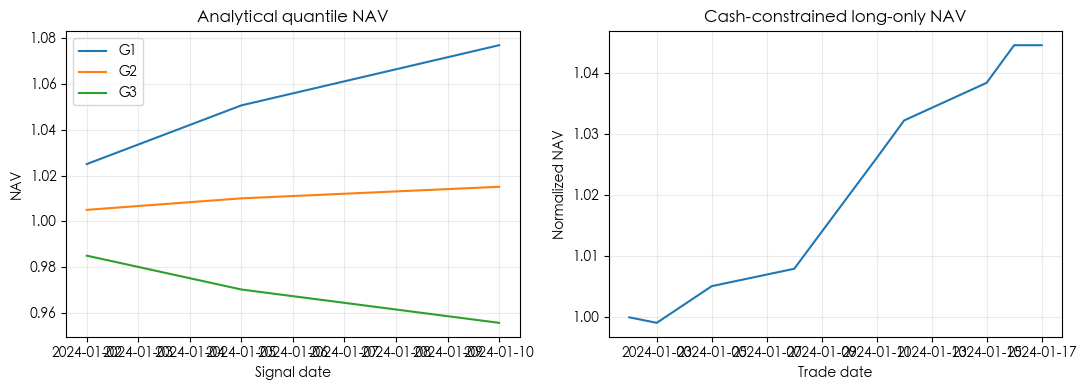

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for column in [name for name in result.quantile_nav.columns if name.startswith('G')]:
    axes[0].plot(result.quantile_nav['signal_date'], result.quantile_nav[column], label=column)
axes[0].set_title('Analytical quantile NAV')
axes[0].set_xlabel('Signal date')
axes[0].set_ylabel('NAV')
axes[0].legend()

portfolio_nav = result.execution.nav
axes[1].plot(portfolio_nav['trade_date'], portfolio_nav['nav'] / portfolio_nav['nav'].iloc[0])
axes[1].set_title('Cash-constrained long-only NAV')
axes[1].set_xlabel('Trade date')
axes[1].set_ylabel('Normalized NAV')
for axis in axes:
    axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

## Takeaways

- The execution schedule uses the strict next open and the following rebalance open without filling missing prices.
- Factor evidence and tradable long-only performance are separate outputs.
- The deliberately blocked buy remains cash rather than becoming an assumed fill.
- Independent cash and P&L attribution checks reconcile the simulated portfolio.
- Full-sample conclusions remain pending until preprocessing and portfolio parameters pass their research stage gates.